In [1]:
import json
from datetime import datetime
from pathlib import Path

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats

In [2]:
input_path = Path("aeris_notebook_input.json")
payload = {"samples": []}

if input_path.exists():
    payload = json.loads(input_path.read_text(encoding="utf-8"))

samples = payload.get("samples") or []
tracer_release_rates = payload.get("tracerReleaseRates") or {}
selection_payload = payload.get("selection") or {}
mission_payload = payload.get("mission") or {}

USING_SYNTHETIC = False

if len(samples) >= 5:
    def _parse_ts(ts):
        for fmt in ("%Y-%m-%dT%H:%M:%S.%fZ", "%Y-%m-%dT%H:%M:%SZ", "%Y-%m-%dT%H:%M:%S",
                    "%Y-%m-%d %H:%M:%S", "%Y-%m-%dT%H:%M:%S.%f"):
            try:
                return datetime.strptime(str(ts), fmt)
            except (ValueError, TypeError):
                continue
        return None

    times = [_parse_ts(s.get("ts", "")) for s in samples]
    ch4_raw = np.array([float(s["methane"] if s.get("methane") is not None else 0.0) for s in samples], dtype=float)
    c2h2_raw = np.array([float(s["acetylene"] if s.get("acetylene") is not None else 0.0) for s in samples], dtype=float)
    c2h2_raw = c2h2_raw / 1000.0  # ppb → ppm
    n2o_raw = np.array([float(s["nitrousOxide"] if s.get("nitrousOxide") is not None else 0.0) for s in samples], dtype=float)

    print(f"Loaded {len(samples)} Aeris samples from {input_path}")
    print(f"CH4:  min={ch4_raw.min():.3f}  max={ch4_raw.max():.3f}  ppm")
    print(f"C2H2: min={c2h2_raw.min():.4f}  max={c2h2_raw.max():.4f}  ppm  (converted from ppb)")
    print(f"N2O:  min={n2o_raw.min():.3f}  max={n2o_raw.max():.3f}  ppm")
    if mission_payload.get("name"):
        print(f"Mission: {mission_payload['name']}")
    if selection_payload.get("sampleCount") is not None:
        print(f"Selected window samples: {selection_payload['sampleCount']}")
else:
    USING_SYNTHETIC = True
    print("Insufficient Aeris data – using synthetic demonstration data")
    rng = np.random.default_rng(42)
    n = 200
    _t0 = datetime(2026, 4, 14, 16, 16, 0)
    times = [_t0.replace(second=0) if i == 0 else
             datetime(2026, 4, 14, 16, 16 + i // 60, i % 60) for i in range(n)]
    plume = np.exp(-((np.arange(n) - 100) ** 2) / (2 * 20 ** 2))
    ch4_raw = 2.15 + 1.2 * plume + rng.normal(0, 0.03, n)
    c2h2_raw = 0.50 + 0.95 * plume + rng.normal(0, 0.02, n)
    n2o_raw = 0.30 + 0.80 * plume + rng.normal(0, 0.15, n)


Loaded 5208 Aeris samples from aeris_notebook_input.json
CH4:  min=0.000  max=4.193  ppm
C2H2: min=-0.0000  max=0.0000  ppm  (converted from ppb)
N2O:  min=0.000  max=0.531  ppm
Mission: LOG_0_2026-02-27_163418-0500
Selected window samples: 5208


In [3]:
def _positive_tracer_rate(value):
    try:
        parsed = float(value)
    except (TypeError, ValueError):
        return None
    return parsed if parsed > 0 else None

BACKGROUND_PERCENTILE = 10
M_CH4 = 16.04
M_C2H2 = 26.04
M_N2O = 44.013

# Convert tracer release rates from L/min → kg/hr (ideal gas, STP: 0 °C, 1 atm, 22.414 L/mol)
_C2H2_LMIN_TO_KGHR = (M_C2H2 / 1000.0 / 22.414) * 60.0   # ≈ 0.0697 kg/hr per L/min
_N2O_LMIN_TO_KGHR  = (M_N2O  / 1000.0 / 22.414) * 60.0   # ≈ 0.1178 kg/hr per L/min

_c2h2_rate_lmin = _positive_tracer_rate(tracer_release_rates.get("acetylene"))
_n2o_rate_lmin  = _positive_tracer_rate(tracer_release_rates.get("nitrousOxide"))

TRACER_ACETYLENE_RELEASE_RATE_KG_HR = (
    _c2h2_rate_lmin * _C2H2_LMIN_TO_KGHR if _c2h2_rate_lmin is not None else None
)
TRACER_NITROUS_OXIDE_RELEASE_RATE_KG_HR = (
    _n2o_rate_lmin * _N2O_LMIN_TO_KGHR if _n2o_rate_lmin is not None else None
)

USE_C2H2_TRACER = TRACER_ACETYLENE_RELEASE_RATE_KG_HR is not None
USE_N2O_TRACER = TRACER_NITROUS_OXIDE_RELEASE_RATE_KG_HR is not None

print(
    "Tracer release rates  |  "
    f"C2H2: {f'{_c2h2_rate_lmin} L/min → {TRACER_ACETYLENE_RELEASE_RATE_KG_HR:.4f} kg/hr' if USE_C2H2_TRACER else 'off'}"
    "  |  "
    f"N2O: {f'{_n2o_rate_lmin} L/min → {TRACER_NITROUS_OXIDE_RELEASE_RATE_KG_HR:.4f} kg/hr' if USE_N2O_TRACER else 'off'}"
)


Tracer release rates  |  C2H2: 10.0 L/min → 0.6971 kg/hr  |  N2O: off


In [4]:
# ch4_bg = np.percentile(ch4_raw, BACKGROUND_PERCENTILE)
# c2h2_bg = np.percentile(c2h2_raw, BACKGROUND_PERCENTILE)
# n2o_bg = np.percentile(n2o_raw, BACKGROUND_PERCENTILE)
ch4_bg = 2.00
c2h2_bg = 0.030
n2o_bg = 0.33

ch4_corr = np.maximum(ch4_raw - ch4_bg, 0.0)
c2h2_corr = np.maximum(c2h2_raw - c2h2_bg, 0.0)
n2o_corr = np.maximum(n2o_raw - n2o_bg, 0.0)

bg_mask = ch4_raw <= np.percentile(ch4_raw, 25)
noise_ch4 = ch4_raw[bg_mask].std() if bg_mask.sum() > 1 else 1e-9
noise_c2h2 = c2h2_raw[bg_mask].std() if bg_mask.sum() > 1 else 1e-9
noise_n2o = n2o_raw[bg_mask].std() if bg_mask.sum() > 1 else 1e-9

snr_ch4 = ch4_corr[ch4_corr > 0].mean() / noise_ch4 if (ch4_corr > 0).any() else 0.0
snr_c2h2 = c2h2_corr[c2h2_corr > 0].mean() / noise_c2h2 if (c2h2_corr > 0).any() else 0.0
snr_n2o = n2o_corr[n2o_corr > 0].mean() / noise_n2o if (n2o_corr > 0).any() else 0.0

print(f"CH4  background: {ch4_bg:.3f} ppm")
print(f"C2H2 background: {c2h2_bg:.3f} ppm")
print(f"N2O  background: {n2o_bg:.3f} ppm")

CH4  background: 2.000 ppm
C2H2 background: 0.030 ppm
N2O  background: 0.330 ppm


C:\Users\Jorge Rangel\AppData\Local\Temp\ipykernel_8648\1850266894.py:17: RuntimeWarning: divide by zero encountered in scalar divide
  snr_ch4 = ch4_corr[ch4_corr > 0].mean() / noise_ch4 if (ch4_corr > 0).any() else 0.0


In [5]:
if USE_N2O_TRACER:
    mask = (ch4_corr > noise_ch4) & (n2o_corr > noise_n2o)

    if mask.sum() >= 3:
        x_reg = n2o_corr[mask]
        y_reg = ch4_corr[mask]
        reg = scipy.stats.linregress(x_reg, y_reg)
        slope = reg.slope
        intercept = reg.intercept
        r2 = reg.rvalue ** 2
    else:
        print("WARNING: too few data points above background concentration")
        x_reg = n2o_corr
        y_reg = ch4_corr
        slope, intercept, r2 = 1.0, 0.0, 0.0

    mole_ratio = slope
    mass_ratio = mole_ratio * (M_CH4 / M_N2O)

    Q_slope = mass_ratio * TRACER_NITROUS_OXIDE_RELEASE_RATE_KG_HR

    sum_n2o = n2o_corr.sum()
    Q_area = ((ch4_corr.sum() / sum_n2o) * (M_CH4 / M_N2O) * TRACER_NITROUS_OXIDE_RELEASE_RATE_KG_HR
              if sum_n2o > 0 else 0.0)

    ered = (abs(Q_area - Q_slope) / ((Q_area + Q_slope) / 2.0) * 100.0
            if (Q_area + Q_slope) > 0 else 0.0)

    print(f"Regression slope: {slope:.4f} ppm/ppm  |  R²: {r2:.3f}")
    print(f"Q_slope: {Q_slope:.2f} kg/hr")
    print(f"Q_area:  {Q_area:.2f} kg/hr")
    print(f"ERED:    {ered:.1f} %")
    print(f"SNR:     {snr_ch4:.2f}  |  SNR_N2O: {snr_n2o:.2f}")
else:
    print("Skipping N2O analysis because its tracer release rate is 0.0 or empty.")

Skipping N2O analysis because its tracer release rate is 0.0 or empty.


In [6]:
if USE_N2O_TRACER:
    x_idx = np.arange(len(ch4_raw))

    tick_step = max(1, len(x_idx) // 6)
    tick_pos = x_idx[::tick_step]
    tick_lbl = [(t.strftime('%H:%M:%S') if t else '') for t in times][::tick_step]

    fig = plt.figure(figsize=(12, 10))
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.52, wspace=0.35)

    def _plume_edges(corr_arr, frac=0.05):
        thresh = corr_arr.max() * frac
        above = x_idx[corr_arr > thresh]
        return (above[0], above[-1]) if len(above) else (None, None)

    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(x_idx, ch4_raw, color='navy', linewidth=1.2, label='CH4 (ppm)')
    ax1.axhline(ch4_bg, color='navy', linestyle='--', linewidth=0.7, alpha=0.45)
    ax1.set_title('Methane in ppm', fontweight='bold')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('CH4 (ppm)')
    ax1.set_xticks(tick_pos)
    ax1.set_xticklabels(tick_lbl, rotation=30, ha='right', fontsize=8)
    ax1.legend(loc='upper left', fontsize=8)
    ax1.text(
        0.01, 0.97,
        f'y = {slope:.4f}x + {intercept:.2f}\nR² = {r2:.3f}',
        transform=ax1.transAxes, va='top', fontsize=8,
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85, boxstyle='round,pad=0.3'),
    )
    e0, e1 = _plume_edges(ch4_corr)
    if e0 is not None:
        ax1.axvline(e0, color='gray', linestyle='--', linewidth=0.8)
        ax1.axvline(e1, color='gray', linestyle='--', linewidth=0.8)

    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(x_idx, n2o_raw, color='darkgreen', linewidth=1.2, label='N2O (ppm)')
    ax2.axhline(n2o_bg, color='darkgreen', linestyle='--', linewidth=0.7, alpha=0.45)
    ax2.set_title('Nitrous Oxide in ppm', fontweight='bold')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('N2O (ppm)')
    ax2.set_xticks(tick_pos)
    ax2.set_xticklabels(tick_lbl, rotation=30, ha='right', fontsize=8)
    ax2.legend(loc='upper left', fontsize=8)
    e0c, e1c = _plume_edges(n2o_corr)
    if e0c is not None:
        ax2.axvline(e0c, color='gray', linestyle='--', linewidth=0.8)
        ax2.axvline(e1c, color='gray', linestyle='--', linewidth=0.8)

    ax3 = fig.add_subplot(gs[2, 0])
    ax3.scatter(x_reg, y_reg, color='tab:blue', s=20, alpha=0.7, label='Corrected points')
    _xline = np.linspace(x_reg.min(), x_reg.max(), 300)
    ax3.plot(_xline, slope * _xline + intercept, color='tab:red', linewidth=2, label='Regression Line')
    ax3.set_xlabel('N2O (ppm, corrected)')
    ax3.set_ylabel('CH4 (ppm, corrected)')
    ax3.legend(loc='upper left', fontsize=8)
    ax3.grid(alpha=0.3)

    ax4 = fig.add_subplot(gs[2, 1])
    ax4.axis('off')
    metrics = (
        'Emission Metrics\n'
        + '─' * 26 + '\n'
        + f'R²:               {r2:.3f}\n'
        + f'Q_area  (kg/hr):  {Q_area:.2f}\n'
        + f'Q_slope (kg/hr):  {Q_slope:.2f}\n'
        + f'ERED (%):         {ered:.1f}\n'
        + f'SNR:              {snr_ch4:.2f}\n'
        + f'SNR_N2O:          {snr_n2o:.2f}'
    )
    ax4.text(
        0.08, 0.90, metrics,
        transform=ax4.transAxes, va='top', fontsize=10,
        fontfamily='monospace',
        bbox=dict(facecolor='lightyellow', edgecolor='gray', alpha=0.95, boxstyle='round,pad=0.55'),
    )

    if USING_SYNTHETIC:
        fig.text(0.5, 0.01, '⚠ Synthetic demo data – connect real Aeris telemetry',
                 ha='center', fontsize=9, color='saddlebrown')

    plt.savefig('aeris_analysis_result_n2o.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('-' * 50)
    print(f'N2O Tracer Release Rate: {TRACER_NITROUS_OXIDE_RELEASE_RATE_KG_HR} kg/hr\n')
    print(f'R2: {r2:.3f}\nQ_area: {Q_area:.2f} kg/hr\nQ_slope: {Q_slope:.2f} kg/hr\n')
    print(f'ERED: {ered:.1f}%\nSNR: {snr_ch4:.2f}\nSNR_N2O: {snr_n2o:.2f}\n')
else:
    print("Skipping N2O figure because its tracer release rate is 0.0 or empty.")

Skipping N2O figure because its tracer release rate is 0.0 or empty.


In [7]:
if USE_C2H2_TRACER:
    mask = (ch4_corr > noise_ch4) & (c2h2_corr > noise_c2h2)

    if mask.sum() >= 3:
        x_reg = c2h2_corr[mask]
        y_reg = ch4_corr[mask]
        reg = scipy.stats.linregress(x_reg, y_reg)
        slope = reg.slope
        intercept = reg.intercept
        r2 = reg.rvalue ** 2
    else:
        print("WARNING: too few data points above background concentration")
        x_reg = c2h2_corr
        y_reg = ch4_corr
        slope, intercept, r2 = 1.0, 0.0, 0.0

    mole_ratio = slope
    mass_ratio = mole_ratio * (M_CH4 / M_C2H2)

    Q_slope = mass_ratio * TRACER_ACETYLENE_RELEASE_RATE_KG_HR

    sum_c2h2 = c2h2_corr.sum()
    Q_area = ((ch4_corr.sum() / sum_c2h2) * (M_CH4 / M_C2H2) * TRACER_ACETYLENE_RELEASE_RATE_KG_HR
              if sum_c2h2 > 0 else 0.0)

    ered = (abs(Q_area - Q_slope) / ((Q_area + Q_slope) / 2.0) * 100.0
            if (Q_area + Q_slope) > 0 else 0.0)

    print(f"Regression slope: {slope:.4f} ppm/ppm  |  R²: {r2:.3f}")
    print(f"Q_slope: {Q_slope:.2f} kg/hr")
    print(f"Q_area:  {Q_area:.2f} kg/hr")
    print(f"ERED:    {ered:.1f} %")
    print(f"SNR:     {snr_ch4:.2f}  |  SNR_C2H2: {snr_c2h2:.2f}")
else:
    print("Skipping C2H2 analysis because its tracer release rate is 0.0 or empty.")

Regression slope: 1.0000 ppm/ppm  |  R²: 0.000
Q_slope: 0.43 kg/hr
Q_area:  0.00 kg/hr
ERED:    200.0 %
SNR:     inf  |  SNR_C2H2: 0.00


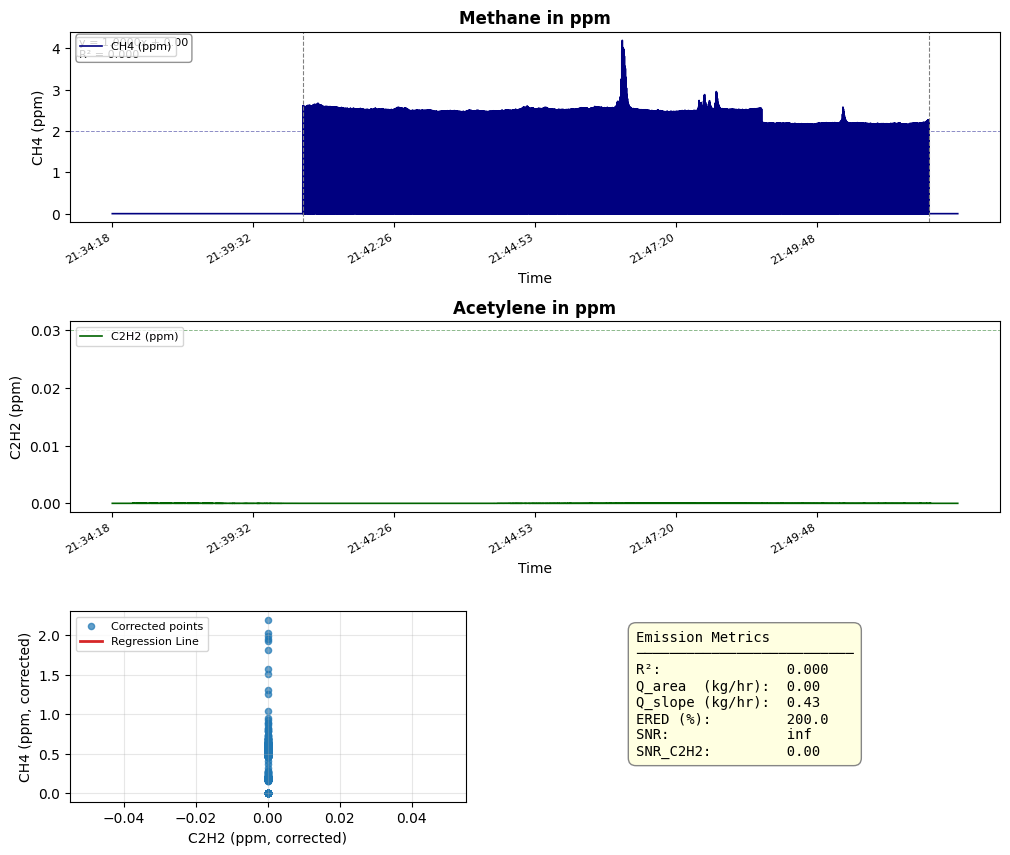

--------------------------------------------------


In [8]:
if USE_C2H2_TRACER:
    x_idx = np.arange(len(ch4_raw))

    tick_step = max(1, len(x_idx) // 6)
    tick_pos = x_idx[::tick_step]
    tick_lbl = [(t.strftime('%H:%M:%S') if t else '') for t in times][::tick_step]

    fig = plt.figure(figsize=(12, 10))
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.52, wspace=0.35)

    def _plume_edges(corr_arr, frac=0.05):
        thresh = corr_arr.max() * frac
        above = x_idx[corr_arr > thresh]
        return (above[0], above[-1]) if len(above) else (None, None)

    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(x_idx, ch4_raw, color='navy', linewidth=1.2, label='CH4 (ppm)')
    ax1.axhline(ch4_bg, color='navy', linestyle='--', linewidth=0.7, alpha=0.45)
    ax1.set_title('Methane in ppm', fontweight='bold')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('CH4 (ppm)')
    ax1.set_xticks(tick_pos)
    ax1.set_xticklabels(tick_lbl, rotation=30, ha='right', fontsize=8)
    ax1.legend(loc='upper left', fontsize=8)
    ax1.text(
        0.01, 0.97,
        f'y = {slope:.4f}x + {intercept:.2f}\nR² = {r2:.3f}',
        transform=ax1.transAxes, va='top', fontsize=8,
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85, boxstyle='round,pad=0.3'),
    )
    e0, e1 = _plume_edges(ch4_corr)
    if e0 is not None:
        ax1.axvline(e0, color='gray', linestyle='--', linewidth=0.8)
        ax1.axvline(e1, color='gray', linestyle='--', linewidth=0.8)

    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(x_idx, c2h2_raw, color='darkgreen', linewidth=1.2, label='C2H2 (ppm)')
    ax2.axhline(c2h2_bg, color='darkgreen', linestyle='--', linewidth=0.7, alpha=0.45)
    ax2.set_title('Acetylene in ppm', fontweight='bold')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('C2H2 (ppm)')
    ax2.set_xticks(tick_pos)
    ax2.set_xticklabels(tick_lbl, rotation=30, ha='right', fontsize=8)
    ax2.legend(loc='upper left', fontsize=8)
    e0c, e1c = _plume_edges(c2h2_corr)
    if e0c is not None:
        ax2.axvline(e0c, color='gray', linestyle='--', linewidth=0.8)
        ax2.axvline(e1c, color='gray', linestyle='--', linewidth=0.8)

    ax3 = fig.add_subplot(gs[2, 0])
    ax3.scatter(x_reg, y_reg, color='tab:blue', s=20, alpha=0.7, label='Corrected points')
    _xline = np.linspace(x_reg.min(), x_reg.max(), 300)
    ax3.plot(_xline, slope * _xline + intercept, color='tab:red', linewidth=2, label='Regression Line')
    ax3.set_xlabel('C2H2 (ppm, corrected)')
    ax3.set_ylabel('CH4 (ppm, corrected)')
    ax3.legend(loc='upper left', fontsize=8)
    ax3.grid(alpha=0.3)

    ax4 = fig.add_subplot(gs[2, 1])
    ax4.axis('off')
    metrics = (
        'Emission Metrics\n'
        + '─' * 26 + '\n'
        + f'R²:               {r2:.3f}\n'
        + f'Q_area  (kg/hr):  {Q_area:.2f}\n'
        + f'Q_slope (kg/hr):  {Q_slope:.2f}\n'
        + f'ERED (%):         {ered:.1f}\n'
        + f'SNR:              {snr_ch4:.2f}\n'
        + f'SNR_C2H2:         {snr_c2h2:.2f}'
    )
    ax4.text(
        0.08, 0.90, metrics,
        transform=ax4.transAxes, va='top', fontsize=10,
        fontfamily='monospace',
        bbox=dict(facecolor='lightyellow', edgecolor='gray', alpha=0.95, boxstyle='round,pad=0.55'),
    )

    if USING_SYNTHETIC:
        fig.text(0.5, 0.01, '⚠ Synthetic demo data – connect real Aeris telemetry',
                 ha='center', fontsize=9, color='saddlebrown')

    plt.savefig('aeris_analysis_result_c2h2.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('-' * 50)
    # print(f'\nC2H2 Tracer Release Rate: {TRACER_ACETYLENE_RELEASE_RATE_KG_HR} kg/hr\n')
    # print(f'R2: {r2:.3f}\n\nQ_area: {Q_area:.2f} kg/hr\n\nQ_slope: {Q_slope:.2f} kg/hr\n')
    # print(f'ERED: {ered:.1f}%\n\nSNR: {snr_ch4:.2f}\n\nSNR_C2H2: {snr_c2h2:.2f}\n')
else:
    print("Skipping C2H2 figure because its tracer release rate is 0.0 or empty.")

In [9]:
# Reserved for future analysis cells.


In [10]:
# Reserved for future analysis cells.


In [11]:
# Reserved for future analysis cells.
